In [1]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate,
    RandomizedSearchCV
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder,
    FunctionTransformer
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier,
)
from xgboost import XGBClassifier
import lightgbm as lgb

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    precision_recall_curve,
    confusion_matrix,
    classification_report,
    RocCurveDisplay,
    PrecisionRecallDisplay,
    roc_curve,
    auc
)

from sklearn.inspection import permutation_importance

import warnings

pd.set_option('display.max_columns', None)

warnings.filterwarnings("ignore")

 **1. LOADING DATA**

In [2]:
cwd = os.getcwd()
dp = os.path.dirname(cwd)
df_raw = pd.read_csv(dp+'\\data\\Telco-Customer-Churn_processed.csv')
df = df_raw.copy(deep=True)
df.SeniorCitizen = df.SeniorCitizen.map({0: "No", 1: "Yes"})

**2. DIVIDING IN TRAIN/TEST**

In [3]:
X = df.drop("Churn",axis = 1)
y = df["Churn"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=52)

**3. ENCODING VARIABLES AND CREATING PIPELINES**

In [4]:
num_cols = ['tenure','MonthlyCharges','TotalCharges', 'TotalServices',
            'ChargesRatio']
cat_bin = ['gender', 'SeniorCitizen','Partner', 'Dependents',
       'PhoneService','PaperlessBilling','HighRiskCustomer']
cat_ohe = ['MultipleLines', 'InternetService', 'OnlineSecurity',
'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
'StreamingMovies', 'Contract',  'PaymentMethod'] 

# Pipeline for numeric variables
num_pipeline = Pipeline([
    ('Imputer',SimpleImputer(strategy="median")),
    ('scaler', StandardScaler())])

#Function for binary variables:
def mapping(X):
    X = pd.DataFrame(X).copy()
    for col in X.columns:
        if col == 'gender':
            X[col] = X[col].map({'Male': 0,'Female': 1})
        else:
            X[col] = X[col].map({'No': 0,'Yes': 1})
    return X

# Preprocessor:
preprocessor = ColumnTransformer(
    transformers=[
        ('numeric', num_pipeline, num_cols),
        ('binary', FunctionTransformer(mapping, feature_names_out="one-to-one"), cat_bin),          
        ('one-hot', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_ohe) 
    ]
)

**4. MODEL1: LOGISTIC REGRESSOR**

In [5]:
y_train_enc = y_train.map({'No': 0, 'Yes': 1})
y_test_enc = y_test.map({'No': 0, 'Yes': 1})

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc",
    "pr_auc": "average_precision"
}

In [6]:
model1 = Pipeline([
    ("preprocessor",preprocessor),
    ("model",LogisticRegression(max_iter=1000,class_weight='balanced'))
])

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=52
)

Hyperparameter tuning was focused on the **PR-AUC metric** (average_precision) to address severe class imbalance and a high volume of true negatives.

In [7]:
param_grid_lr = {
    "model__C": [10.0,12.5,15.0,17.5,20.0],
    "model__solver": ['lbfgs','liblinear','sag','saga'],
    "model__max_iter": [50, 75, 100, 125, 150],
}

search_lr = RandomizedSearchCV(
    estimator= model1,
    param_distributions=param_grid_lr,
    n_iter=30,
    scoring="average_precision",
    cv=cv,
    n_jobs=-1,
    random_state=52,
    verbose=1
)

search_lr.fit(
    X_train,
    y_train_enc
)

print(search_lr.best_params_)
print(search_lr.best_score_)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
{'model__solver': 'saga', 'model__max_iter': 100, 'model__C': 15.0}
0.6651606641304313


In [8]:
model_lr = search_lr.best_estimator_

cv_results_lr = cross_validate(
    model_lr,
    X_train,
    y_train_enc,
    cv=cv,
    scoring=scoring,
    n_jobs=-1,
    error_score='raise' 
)

for metric in scoring:
    values = cv_results_lr[f"test_{metric}"]
    print(
        f"{metric}: "
        f"{values.mean():.3f} "
        f"+/- {values.std():.3f}"
    )

accuracy: 0.749 +/- 0.011
precision: 0.517 +/- 0.014
recall: 0.809 +/- 0.022
f1: 0.631 +/- 0.015
roc_auc: 0.847 +/- 0.009
pr_auc: 0.665 +/- 0.011


The optimized model achieved a PR-AUC value of approximately 0.66 against a positive class prevalence of 26.54%. This represents a solid initial baseline, though there remains scope for further optimization.

**5. MODEL2: RANDOM FOREST CLASSIFIER**

In [9]:
model2 = Pipeline([
    ("preprocessor",preprocessor),
    ("model",RandomForestClassifier(n_estimators=500,random_state=52,n_jobs=-1,
                                    class_weight="balanced"))
])

param_grid_rf = {
    "model__n_estimators": [25, 37, 50, 62, 75, 100, 200, 250, 300],
    "model__max_depth": [5, 7, 10,15, 20, 30],
    "model__min_samples_split": [5, 7, 8,9,10,11,12,15,17],
    "model__min_samples_leaf": [5,6,7,8,9, 10],
    "model__max_features": ["sqrt","log2"],
}

search_rf = RandomizedSearchCV(
    estimator=model2,
    param_distributions=param_grid_rf,
    n_iter=30,
    scoring="average_precision",
    cv=cv,
    n_jobs=-1,
    random_state=52,
    verbose=1
)

search_rf.fit(
    X_train,
    y_train_enc
)

print(search_rf.best_params_)
print(search_rf.best_score_)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
{'model__n_estimators': 200, 'model__min_samples_split': 17, 'model__min_samples_leaf': 10, 'model__max_features': 'log2', 'model__max_depth': 10}
0.6547965607622389


In [10]:
model_rf = search_rf.best_estimator_

cv_results_rf = cross_validate(
    model_rf,
    X_train,
    y_train_enc,
    cv=cv,
    scoring=scoring,
    n_jobs=-1,
    error_score='raise' 
)

for metric in scoring:
    values = cv_results_rf[f"test_{metric}"]
    print(
        f"{metric}: "
        f"{values.mean():.3f} "
        f"+/- {values.std():.3f}"
    )

accuracy: 0.770 +/- 0.016
precision: 0.548 +/- 0.022
recall: 0.777 +/- 0.023
f1: 0.643 +/- 0.021
roc_auc: 0.845 +/- 0.010
pr_auc: 0.655 +/- 0.012


**6. MODEL3: LIGHTGMB**

In [11]:

model3 = Pipeline([
    ("preprocessor",preprocessor),
    ("model",lgb.LGBMClassifier(random_state=52,is_unbalance = True,importance_type='gain'))
])

param_grid_lgb = {
    "model__num_leaves": [10, 15, 25, 50, 75, 100, 125],
    "model__max_depth": [-1, 3, 5, 7, 9],
    "model__learning_rate": [0.005, 0.01, 0.05, 0.1, 0.2, 0.3],
    "model__n_estimators": [37, 50, 62, 75, 100, 200],
    "model__min_child_samples": [10,30,50,70,90,110],
    "model__reg_alpha": [0, 1e-3, 0.01, 0.1, 1, 10,100],      # L1 regularization
    "model__reg_lambda": [0, 1e-3, 0.01, 0.1, 1, 10],     # L2 regularization
}

   
search_lgb = RandomizedSearchCV(
    estimator=model3,
    param_distributions=param_grid_lgb,
    n_iter=30,
    scoring="average_precision",
    cv=cv,
    n_jobs=-1,
    random_state=52,
    verbose=1
)

search_lgb.fit(
    X_train,
    y_train_enc
)


Fitting 5 folds for each of 30 candidates, totalling 150 fits
[LightGBM] [Info] Number of positive: 1495, number of negative: 4139
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002086 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 924
[LightGBM] [Info] Number of data points in the train set: 5634, number of used features: 43
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.265353 -> initscore=-1.018328
[LightGBM] [Info] Start training from score -1.018328
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -in

RandomizedSearchCV(cv=StratifiedKFold(n_splits=5, random_state=52, shuffle=True),
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('numeric',
                                                                               Pipeline(steps=[('Imputer',
                                                                                                SimpleImputer(strategy='median')),
                                                                                               ('scaler',
                                                                                                StandardScaler())]),
                                                                               ['tenure',
                                                                                'MonthlyCharges',
                                                                                'TotalCharges',
                                                                                'TotalServices',
                                                                                'ChargesRatio']),
                                                                              ('binary',
                                                                               FunctionTr...
                   param_distributions={'model__learning_rate': [0.005, 0.01,
                                                                 0.05, 0.1, 0.2,
                                                                 0.3],
                                        'model__max_depth': [-1, 3, 5, 7, 9],
                                        'model__min_child_samples': [10, 30, 50,
                                                                     70, 90,
                                                                     110],
                                        'model__n_estimators': [37, 50, 62, 75,
                                                                100, 200],
                                        'model__num_leaves': [10, 15, 25, 50,
                                                              75, 100, 125],
                                        'model__reg_alpha': [0, 0.001, 0.01,
                                                             0.1, 1, 10, 100],
                                        'model__reg_lambda': [0, 0.001, 0.01,
                                                              0.1, 1, 10]},
                   random_state=52, scoring='average_precision', verbose=1)

In [12]:
print(search_lgb.best_params_)
print(search_lgb.best_score_)

{'model__reg_lambda': 0.1, 'model__reg_alpha': 0.1, 'model__num_leaves': 50, 'model__n_estimators': 75, 'model__min_child_samples': 110, 'model__max_depth': 3, 'model__learning_rate': 0.1}
0.6587064194258485


In [13]:
model_lgb = search_lgb.best_estimator_

cv_results_lgb = cross_validate(
    model_lgb,
    X_train,
    y_train_enc,
    cv=cv,
    scoring=scoring,
    n_jobs=-1,
    error_score='raise' 
)

for metric in scoring:
    values = cv_results_lgb[f"test_{metric}"]
    print(
        f"{metric}: "
        f"{values.mean():.3f} "
        f"+/- {values.std():.3f}"
    )

accuracy: 0.754 +/- 0.017
precision: 0.525 +/- 0.021
recall: 0.805 +/- 0.023
f1: 0.635 +/- 0.021
roc_auc: 0.845 +/- 0.009
pr_auc: 0.659 +/- 0.006


The feature importances for this model according to *importance_type=gain*:

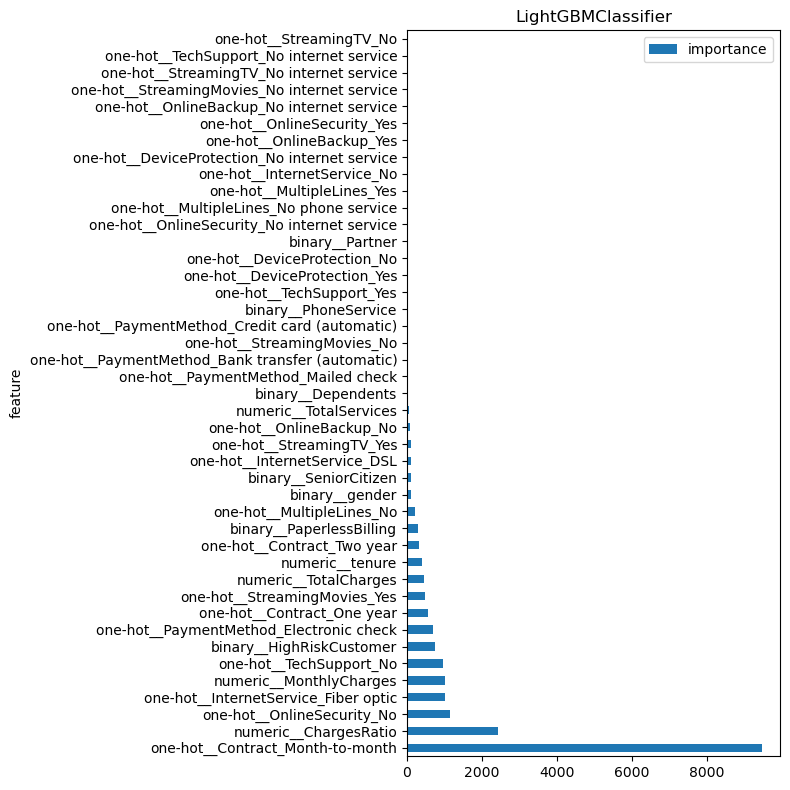

In [14]:
feature_names = model_lgb.named_steps['preprocessor'].get_feature_names_out()
importances = model_lgb.named_steps['model'].feature_importances_

importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values(by='importance', ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(8,8))
importance_df.plot.barh(x='feature',y='importance',title = 'LightGBMClassifier',ax = ax)
plt.tight_layout()
plt.savefig(dp+f'\\reports\\figures\\11_feature_importance_LGBMClassifier.png')
plt.show()

**7. MODEL5: XGBoost Classifier**

In [15]:
count_neg = (y_train_enc == 0).sum()
count_pos = (y_train_enc == 1).sum()
ratio = count_neg / count_pos

model4 = Pipeline([
    ("preprocessor",preprocessor),
    ("model",XGBClassifier(random_state=52,scale_pos_weight = ratio,
                           eval_metric='logloss',importance_type='gain'))
])

param_grid_xbc = {
    "model__max_depth": [-1, 3, 5, 7, 9],
    "model__learning_rate": [0.005, 0.01, 0.05, 0.1, 0.2, 0.3],
    "model__n_estimators": [50, 75, 100, 125, 150, 175, 200, 250],
    "model__min_child_weight": [1,4,7,10],
    "model__alpha": [0, 1e-3, 0.01, 0.1, 1, 10],      
    "model__lambda": [0, 1e-3, 0.01, 0.1, 1, 10],     
    "model__gamma": [0, 1e-3, 0.01, 0.1, 1, 5],
}

   
search_xbc = RandomizedSearchCV(
    estimator=model4,
    param_distributions=param_grid_xbc,
    n_iter=30,
    scoring="average_precision",
    cv=cv,
    n_jobs=-1,
    random_state=52,
    verbose=1
)

search_xbc.fit(
    X_train,
    y_train_enc
)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


RandomizedSearchCV(cv=StratifiedKFold(n_splits=5, random_state=52, shuffle=True),
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('numeric',
                                                                               Pipeline(steps=[('Imputer',
                                                                                                SimpleImputer(strategy='median')),
                                                                                               ('scaler',
                                                                                                StandardScaler())]),
                                                                               ['tenure',
                                                                                'MonthlyCharges',
                                                                                'TotalCharges',
                                                                                'TotalServices',
                                                                                'ChargesRatio']),
                                                                              ('binary',
                                                                               FunctionTr...
                   param_distributions={'model__alpha': [0, 0.001, 0.01, 0.1, 1,
                                                         10],
                                        'model__gamma': [0, 0.001, 0.01, 0.1, 1,
                                                         5],
                                        'model__lambda': [0, 0.001, 0.01, 0.1,
                                                          1, 10],
                                        'model__learning_rate': [0.005, 0.01,
                                                                 0.05, 0.1, 0.2,
                                                                 0.3],
                                        'model__max_depth': [-1, 3, 5, 7, 9],
                                        'model__min_child_weight': [1, 4, 7,
                                                                    10],
                                        'model__n_estimators': [50, 75, 100,
                                                                125, 150, 175,
                                                                200, 250]},
                   random_state=52, scoring='average_precision', verbose=1)

In [16]:
print(search_xbc.best_params_)
print(search_xbc.best_score_)

{'model__n_estimators': 200, 'model__min_child_weight': 7, 'model__max_depth': 3, 'model__learning_rate': 0.05, 'model__lambda': 0.1, 'model__gamma': 0.1, 'model__alpha': 10}
0.6608841396196824


In [17]:
model_xbc = search_xbc.best_estimator_

cv_results_xbc = cross_validate(
    model_lgb,
    X_train,
    y_train_enc,
    cv=cv,
    scoring=scoring,
    n_jobs=-1,
    error_score='raise' 
)

for metric in scoring:
    values = cv_results_xbc[f"test_{metric}"]
    print(
        f"{metric}: "
        f"{values.mean():.3f} "
        f"+/- {values.std():.3f}"
    )

accuracy: 0.754 +/- 0.017
precision: 0.525 +/- 0.021
recall: 0.805 +/- 0.023
f1: 0.635 +/- 0.021
roc_auc: 0.845 +/- 0.009
pr_auc: 0.659 +/- 0.006


The feature importances for this model according to *importance_type=gain*:

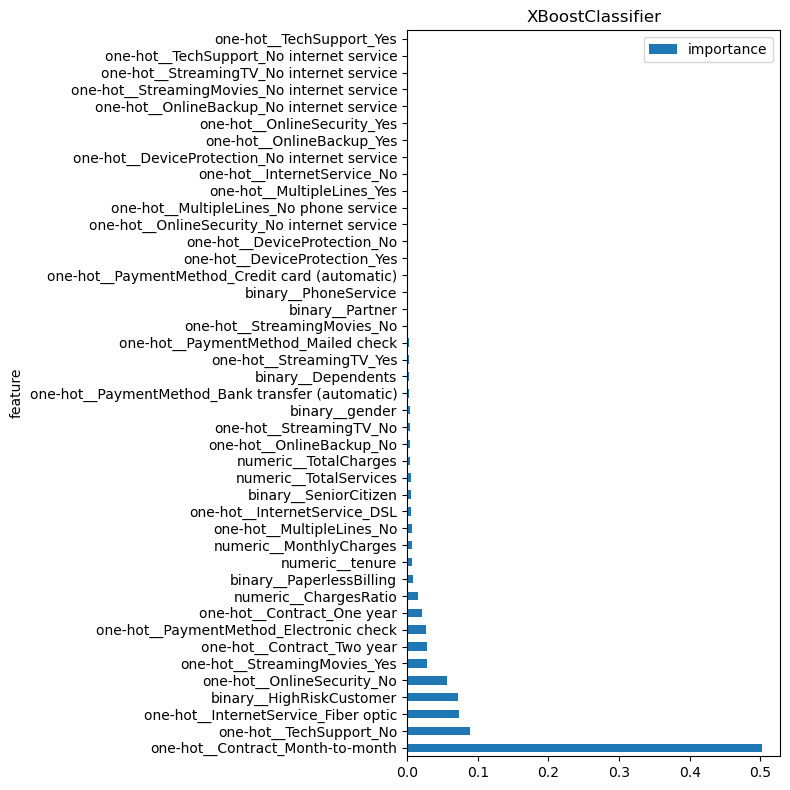

In [18]:
feature_names = model_xbc.named_steps['preprocessor'].get_feature_names_out()
importances = model_xbc.named_steps['model'].feature_importances_

importance_df2 = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values(by='importance', ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(8,8))
importance_df2.plot.barh(x='feature',y='importance',title='XBoostClassifier',ax = ax)
plt.tight_layout()
plt.savefig(dp+f'\\reports\\figures\\12_feature_importance_XBoost Classifier.png')
plt.show()    

In summary:

In [19]:
results = pd.DataFrame({
    "LogisticRegression": {
        metric: cv_results_lr[f"test_{metric}"].mean()
        for metric in scoring
    },
    "RandomForestClassifier": {
        metric: cv_results_rf[f"test_{metric}"].mean()
        for metric in scoring
    },
    "LightGMBClassifier": {
        metric: cv_results_lgb[f"test_{metric}"].mean()
        for metric in scoring
    },
    "XBoostClassifier": {
        metric: cv_results_xbc[f"test_{metric}"].mean()
        for metric in scoring
    },
})

results

,LogisticRegression,RandomForestClassifier,LightGMBClassifier,XBoostClassifier
accuracy,0.749022,0.770321,0.754346,0.754346
precision,0.517467,0.547771,0.524660,0.524660
recall,0.808696,0.777258,0.804682,0.804682
f1,0.631017,0.642507,0.635031,0.635031
roc_auc,0.846952,0.844753,0.845440,0.845440
pr_auc,0.665176,0.654797,0.658706,0.658706


**8. COMPARE ALL MODEL PERFORMANCES**

In [20]:
y_pred_lr = model_lr.predict(X_test)
y_pred_rf = model_rf.predict(X_test)
y_pred_lgb = model_lgb.predict(X_test)
y_pred_xbc = model_xbc.predict(X_test)

In [21]:
ls = [y_pred_lr,y_pred_rf, y_pred_lgb,y_pred_xbc]
alg = ["LogisticRegression", "RandomForestClassifier", "LightGMBClassifier", "XBoostClassifier"]
i = 0
while i < len(ls):
    print(alg[i])
    print(classification_report(y_test_enc,ls[i]))
    i+=1

LogisticRegression
              precision    recall  f1-score   support

           0       0.92      0.74      0.82      1035
           1       0.53      0.81      0.64       374

    accuracy                           0.76      1409
   macro avg       0.72      0.78      0.73      1409
weighted avg       0.81      0.76      0.77      1409

RandomForestClassifier
              precision    recall  f1-score   support

           0       0.90      0.77      0.83      1035
           1       0.55      0.77      0.64       374

    accuracy                           0.77      1409
   macro avg       0.73      0.77      0.74      1409
weighted avg       0.81      0.77      0.78      1409

LightGMBClassifier
              precision    recall  f1-score   support

           0       0.91      0.75      0.82      1035
           1       0.54      0.80      0.64       374

    accuracy                           0.76      1409
   macro avg       0.72      0.77      0.73      1409
weighted avg 

Now we are going to optimise the threshold:

The mathematically optimal threshold is: 0.6318
Using the optimal threshold, the estimated maximum F1-Score: 0.66%


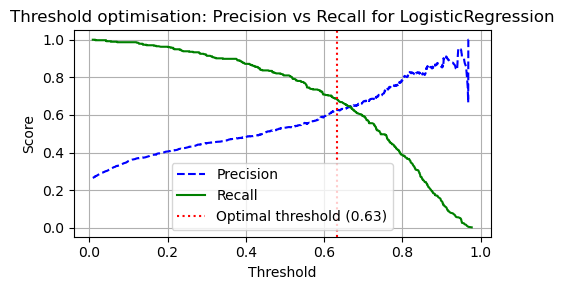

The mathematically optimal threshold is: 0.5851
Using the optimal threshold, the estimated maximum F1-Score: 0.65%


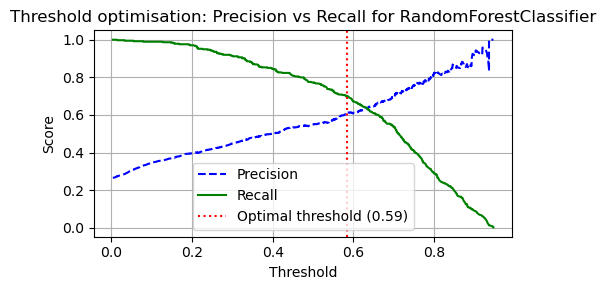

The mathematically optimal threshold is: 0.5407
Using the optimal threshold, the estimated maximum F1-Score: 0.65%


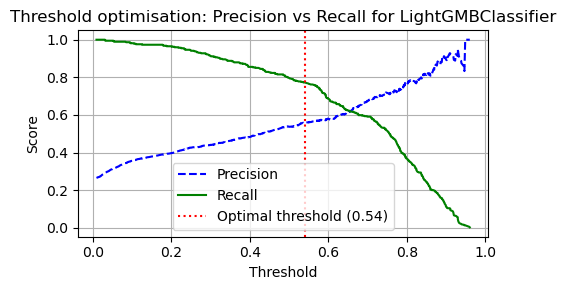

The mathematically optimal threshold is: 0.4976
Using the optimal threshold, the estimated maximum F1-Score: 0.65%


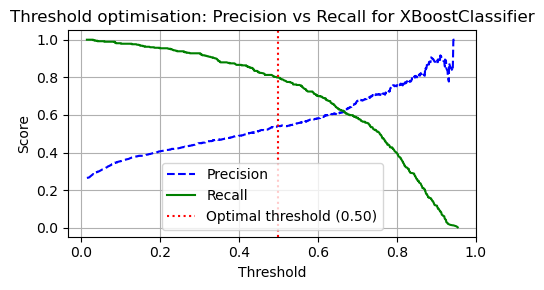

In [22]:
mod = [model_lr, model_rf, model_lgb, model_xbc]
i = 0
th = []
while i < len(mod):
    y_probs = mod[i].predict_proba(X_test)[:, 1]
    precisions, recalls, thresholds = precision_recall_curve(y_test_enc, y_probs)
    
    f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)
    
    # Searching the higher F1-Score 
    best_idx = np.argmax(f1_scores[:-1])
    best_threshold = thresholds[best_idx]
    best_f1 = f1_scores[best_idx]
    
    th.append(float(best_threshold))
    
    print(f"The mathematically optimal threshold is: {best_threshold:.4f}")
    print(f"Using the optimal threshold, the estimated maximum F1-Score: {best_f1:.2f}%")
    
    # Precision-Recall curve
    plt.figure(figsize=(5, 3))
    plt.plot(thresholds, precisions[:-1], 'b--', label='Precision')
    plt.plot(thresholds, recalls[:-1], 'g-', label='Recall')
    plt.axvline(best_threshold, color='red', linestyle=':', label=f'Optimal threshold ({best_threshold:.2f})')
    
    plt.title(f'Threshold optimisation: Precision vs Recall for {alg[i]}')
    plt.xlabel('Threshold')
    plt.ylabel('Score')
    plt.legend(loc='best')
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(dp+f'\\reports\\figures\\13_optimised_threshold_{alg[i]}.png')
    plt.show()
    
    i+=1

Next, we will be computing the classification reports and confusion matrices, utilizing the newly optimized threshold determined for each model.

In [23]:
y_proba_lr = model_lr.predict_proba(X_test)[:,1]
y_proba_rf = model_rf.predict_proba(X_test)[:,1]
y_proba_lgb = model_lgb.predict_proba(X_test)[:,1]
y_proba_xbc = model_xbc.predict_proba(X_test)[:,1]

y_pred_lr_nt = (y_proba_lr >= th[0]).astype(int)
y_pred_rf_nt = (y_proba_rf >= th[1]).astype(int)
y_pred_lgb_nt = (y_proba_lgb >= th[2]).astype(int)
y_pred_xbc_nt = (y_proba_xbc >= th[3]).astype(int)

ls_nt = [y_pred_lr_nt,y_pred_rf_nt, y_pred_lgb_nt,y_pred_xbc_nt]
i = 0
while i < len(ls_nt):
    print(alg[i])
    print(classification_report(y_test_enc,ls_nt[i]))
    i+=1

LogisticRegression
              precision    recall  f1-score   support

           0       0.88      0.85      0.87      1035
           1       0.63      0.69      0.66       374

    accuracy                           0.81      1409
   macro avg       0.76      0.77      0.76      1409
weighted avg       0.82      0.81      0.81      1409

RandomForestClassifier
              precision    recall  f1-score   support

           0       0.89      0.84      0.86      1035
           1       0.61      0.70      0.65       374

    accuracy                           0.80      1409
   macro avg       0.75      0.77      0.76      1409
weighted avg       0.81      0.80      0.81      1409

LightGMBClassifier
              precision    recall  f1-score   support

           0       0.91      0.78      0.84      1035
           1       0.56      0.77      0.65       374

    accuracy                           0.78      1409
   macro avg       0.73      0.78      0.75      1409
weighted avg 

ROC curves:

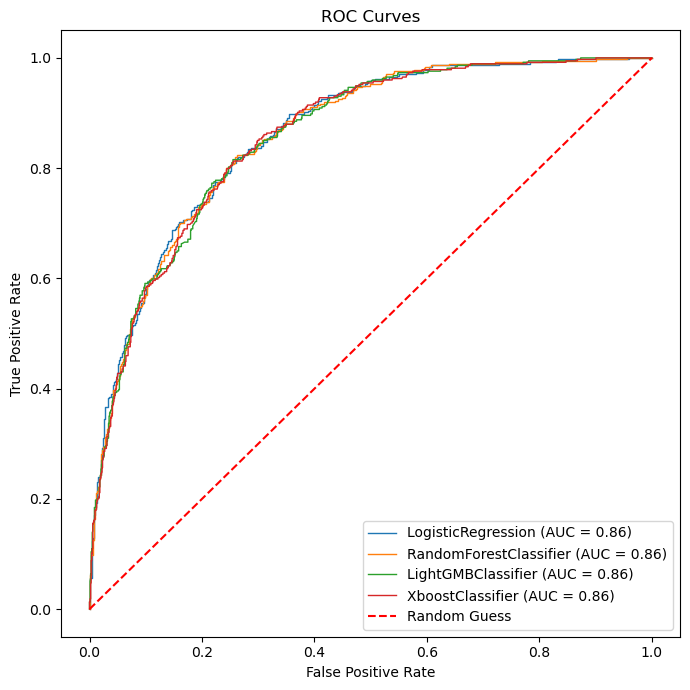

In [24]:
test_prob = pd.DataFrame(
    {'True': y_test_enc,
     'LogisticRegression':y_proba_lr,
     'RandomForestClassifier':y_proba_rf,
     'LightGMBClassifier':y_proba_lgb,
     'XboostClassifier':y_proba_xbc
     }
)

plt.figure(figsize=(7, 7))
for model in test_prob.columns[1:]:
    fpr, tpr, _ = roc_curve(test_prob['True'], test_prob[model])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{model} (AUC = {roc_auc:.2f})',lw = 1)

plt.plot([0, 1], [0, 1], 'r--', label='Random Guess')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves')
plt.legend()
plt.tight_layout()
plt.savefig(dp+'\\reports\\figures\\14_roc_curve.png')
plt.show()

Precision-Recall curve:

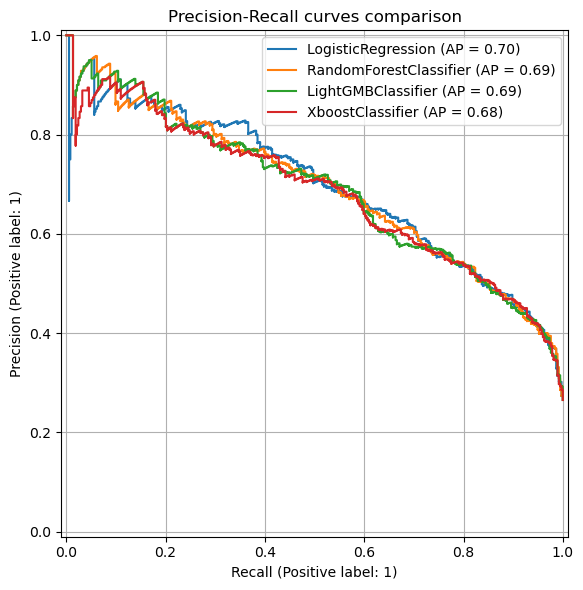

In [25]:
fig, ax = plt.subplots(figsize=(6, 6))

PrecisionRecallDisplay.from_predictions(
    y_test_enc, y_proba_lr, ax=ax, name="LogisticRegression"
)
PrecisionRecallDisplay.from_predictions(
    y_test_enc, y_proba_rf, ax=ax, name="RandomForestClassifier"
)
PrecisionRecallDisplay.from_predictions(
    y_test_enc, y_proba_lgb, ax=ax, name="LightGMBClassifier"
)
PrecisionRecallDisplay.from_predictions(
    y_test_enc, y_proba_xbc, ax=ax, name="XboostClassifier"
)

ax.set_title("Precision-Recall curves comparison")
plt.legend(loc="upper right")
plt.grid(True)
plt.tight_layout()
plt.savefig(dp+'\\reports\\figures\\15_precision_recall_curve.png')
plt.show()

Confusion matrices:


Accuracy: 80.91%


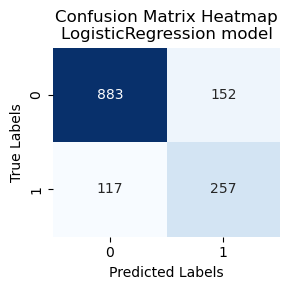

LogisticRegression model
 [[62.67 10.79]
 [ 8.3  18.24]]

Accuracy: 80.20%


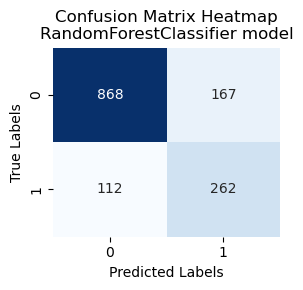

RandomForestClassifier model
 [[61.6  11.85]
 [ 7.95 18.59]]

Accuracy: 78.00%


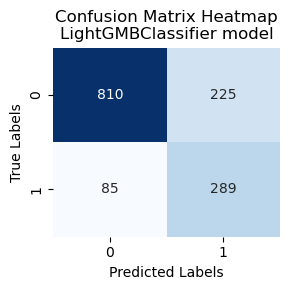

LightGMBClassifier model
 [[57.49 15.97]
 [ 6.03 20.51]]

Accuracy: 76.72%


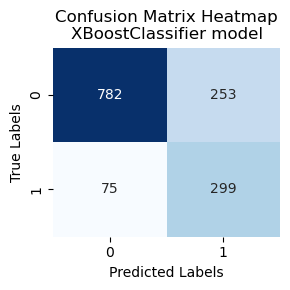

XBoostClassifier model
 [[55.5  17.96]
 [ 5.32 21.22]]


In [26]:
i = 0
cmat = pd.DataFrame({
    'Accuracy':[],
    'TrueNegatives':[],
    'FalsePositives':[],
    'FalseNegatives':[],
    'TruePositives':[],
    })

while i < len(ls_nt):
    accuracy2 = accuracy_score(y_test_enc, ls_nt[i])
    print(f'\nAccuracy: {accuracy2 * 100:.2f}%')
    
    conf_matrix2 = confusion_matrix(y_test_enc, ls_nt[i])
   
    plt.figure(figsize=(3, 3))
    sns.heatmap(conf_matrix2, annot=True, fmt='g', cmap='Blues', cbar=False)
    plt.title(f'Confusion Matrix Heatmap\n{alg[i]} model')
    plt.xlabel('Predicted Labels')
    plt.ylabel('True Labels')
    plt.tight_layout()
    plt.savefig(dp+f'\\reports\\figures\\15_optimised_confusion_matrix_{alg[i]}.png')
    plt.show()
    
    new_mat = np.round(100*(conf_matrix2/len(y_test_enc)),2)
    
    new_row = pd.DataFrame({
        'Accuracy':[accuracy2],
        'TrueNegatives':[new_mat[0,0]],
        'FalsePositives':[new_mat[0,1]],
        'FalseNegatives':[new_mat[1,0]],
        'TruePositives':[new_mat[1,1]],
        },
        index = [f'{alg[i]}'])
    cmat = pd.concat([cmat, new_row])
    
    print(f"{alg[i]} model\n {new_mat}")
    
    i+=1

rec = []
for pred in ls_nt:
    rec.append(float(np.round(recall_score(y_test_enc, pred, average='binary'),2)))
    
cmat['Recall'] = rec

## CONCLUSIONS

In [27]:
cmat #is in PERCENTAGES

,Accuracy,TrueNegatives,FalsePositives,FalseNegatives,TruePositives,Recall
LogisticRegression,0.809084,62.67,10.79,8.30,18.24,0.69
RandomForestClassifier,0.801987,61.60,11.85,7.95,18.59,0.70
LightGMBClassifier,0.779986,57.49,15.97,6.03,20.51,0.77
XBoostClassifier,0.767211,55.50,17.96,5.32,21.22,0.80


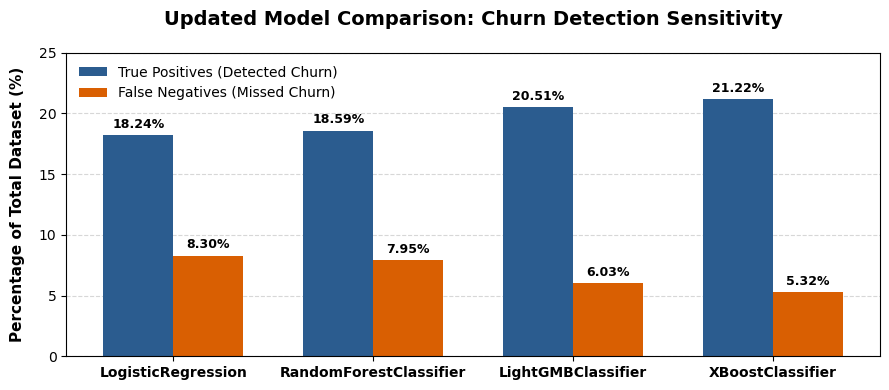

In [28]:
models = cmat.index.tolist()
true_positives = (cmat['TruePositives']).tolist()
false_negatives = (cmat['FalseNegatives']).tolist()

x = np.arange(len(models))  
width = 0.35  

fig, ax = plt.subplots(figsize=(9, 4))


rects1 = ax.bar(x - width/2, true_positives, width, label='True Positives (Detected Churn)', color='#2b5c8f')
rects2 = ax.bar(x + width/2, false_negatives, width, label='False Negatives (Missed Churn)', color='#d95f02')


ax.set_ylabel('Percentage of Total Dataset (%)', fontsize=11, fontweight='bold', labelpad=10)
ax.set_title('Updated Model Comparison: Churn Detection Sensitivity', fontsize=14, fontweight='bold', pad=20)
ax.set_xticks(x)

ax.set_xticklabels(models, fontsize=10, fontweight='bold')
ax.set_ylim(0, 25)  
ax.grid(axis='y', linestyle='--', alpha=0.5)
ax.set_axisbelow(True)  
ax.legend( fontsize=10, frameon=True, facecolor='white', edgecolor='none')


def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}%',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9, fontweight='semibold')

autolabel(rects1)
autolabel(rects2)

plt.tight_layout()
plt.savefig(dp+f'\\reports\\figures\\16_churn_detection_sensitivity.png')
plt.show()

*Note: every time this code reruns, results and conclusions might vary.*

- **XGBoost Classifier** (Maximum Sensitivity & Risk Mitigation): The XGBoost classifier delivers the most powerful performance regarding churn identification, achieving an outstanding 80.00% Recall. It minimises False Negatives to just 5.32%, meaning it successfully captures 21.22% out of the total 26.54% of churning customers. This model represents the optimal choice if the primary business mandate is to *prevent customer flight* at all costs. However, this high sensitivity results in a 17.96% False Positive rate, which could lead to *unnecessary marketing expenditure* on loyal clients.

- **Logistic Regression** (High Precision & Cost Efficiency): In direct contrast to the previous iteration, Logistic Regression now yields the highest overall accuracy (80.91%) and the lowest False Positive rate (10.79%). This model is highly conservative and exceptionally cost-efficient, making it ideal if the *budget for retention campaigns is strictly limited*, as it prevents wasting resources on customers who have no intention of leaving. The compromise is a *higher rate of missed churners* (False Negatives at 8.30%).

- **Random Forest Classifier** and **LightGBM Classifier** (Intermediate Solutions): Random Forest performs comparably to Logistic Regression but with slightly lower accuracy, while LightGBM shifts to a high-recall posture (77.00%), acting as a *well-balanced bridge* between the conservative approach of Logistic Regression and the aggressive detection of XGBoost.


### Final Recommendation:
The strategic selection remains dependent on operational priorities:

- XGBoost Classifier is the recommended candidate for deployment if the business objective focuses on maximising customer retention, as it captures 4 out of 5 churn events.
- Conversely, if mitigating operational costs and campaign waste is the priority, Logistic Regression offers the most stable and precise alternative.
